# SEED-OLF Public-Data Baseline Effects

## tl;dr

- The executed dataset contains **2,304 stimulation trials from 32 participants and 3 sessions per participant**.
- The subjective class-1 rate is **43.3%**; odor identity is therefore evaluated as a mandatory shortcut baseline.
- Under leave-one-subject-out evaluation, the odor-only prior achieved log loss **0.441** and balanced accuracy **0.809**.
- Adding paired stimulation–recovery EEG features produced log loss **0.455** and balanced accuracy **0.786**. Its participant-block mean log-loss improvement over odor prior was **-0.014** (95% CI **-0.028 to 0.000**). Positive values favor EEG.
- The spatial OAS covariance + Log-Euclidean model produced LOSO log loss **0.567** and balanced accuracy **0.736**; it also did not beat the odor prior.
- **9/10** global spectral stimulation–recovery effects passed within-family FDR control; **8/40** odor-band features reached ICC(2,1) ≥ 0.5.
- Frequency interpretation currently uses **200 Hz inferred from 3,000 samples over the reported 15-second stage**. This remains a metadata assumption, and clean breathing is a post-stimulus recovery condition rather than a pre-stimulus baseline.


## Context & Methods

This notebook is an executed reader-facing companion to `scripts/run_baselines.py`. The primary unit is a participant-session-trial. Leave-one-subject-out and within-participant leave-one-session-out splits are assigned before fitted transformations. Odor priors are learned inside each training fold.

### Key Assumptions

- Sampling rate is provisionally 200 Hz, inferred from the reported 15-second stage and 3,000 samples.
- `clean_breathing` is interpreted as post-stimulus recovery, not a pre-stimulus causal baseline.
- Channel order is not embedded in the files, so this first notebook reports channel-aggregated spectral effects and does not make scalp-topography claims.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
OUTPUT_DIR = Path('artifacts/baseline_v1')
manifest = pd.read_csv(OUTPUT_DIR / "manifest.csv")
effects = pd.read_csv(OUTPUT_DIR / "paired_spectral_effects.csv")
reliability = pd.read_csv(OUTPUT_DIR / "cross_session_reliability.csv")
prediction_summary = pd.read_csv(OUTPUT_DIR / "prediction_summary.csv")
incremental_value = pd.read_csv(OUTPUT_DIR / "incremental_value.csv")
metadata = json.loads((OUTPUT_DIR / "run_metadata.json").read_text())


## Data

### 1. Confirm trial structure and labels

In [2]:
dataset_summary = pd.DataFrame({
    "value": [
        len(manifest), manifest.subject.nunique(), manifest.session.nunique(),
        manifest.trial.nunique(), manifest.y_emotion.mean()
    ]
}, index=["trials", "subjects", "sessions", "trials_per_session", "class_1_rate"])
display(dataset_summary)
display(pd.crosstab(manifest.y_odor, manifest.y_emotion, margins=True))


,value
trials,2304.00000
subjects,32.00000
sessions,3.00000
trials_per_session,24.00000
class_1_rate,0.43316


y_emotion,0,1,All
y_odor,,,
1,489,87,576
2,514,62,576
3,46,530,576
4,257,319,576
All,1306,998,2304


## Results

### 2. Paired stimulation–recovery spectral effects

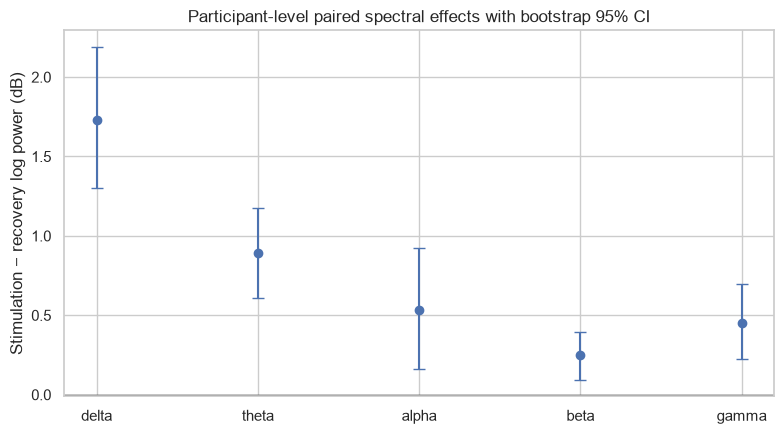

,feature_family,band,n_subjects,mean_stim_minus_recovery,ci95_lower,ci95_upper,cohen_dz,t_statistic,t_p_value,wilcoxon_statistic,wilcoxon_p_value,wilcoxon_q_value
0,logbp,delta,32,1.7311,1.3043,2.1886,1.3246,7.4931,0.0000,10.0,0.0000,0.0000
8,relbp,beta,32,-0.0225,-0.0314,-0.0147,-0.9031,-5.1085,0.0000,14.0,0.0000,0.0000
1,logbp,theta,32,0.8895,0.6088,1.1735,1.0635,6.0159,0.0000,31.0,0.0000,0.0000
5,relbp,delta,32,0.0524,0.0319,0.0731,0.8780,4.9669,0.0000,53.0,0.0000,0.0001
9,relbp,gamma,32,-0.0076,-0.0115,-0.0038,-0.6915,-3.9116,0.0005,70.0,0.0001,0.0002
6,relbp,theta,32,-0.0096,-0.0138,-0.0056,-0.7880,-4.4577,0.0001,74.0,0.0002,0.0003
4,logbp,gamma,32,0.4538,0.2218,0.7000,0.6346,3.5901,0.0011,96.0,0.0011,0.0016
3,logbp,beta,32,0.2476,0.0934,0.3963,0.5522,3.1235,0.0039,120.0,0.0061,0.0076
2,logbp,alpha,32,0.5360,0.1648,0.9254,0.4686,2.6507,0.0125,135.0,0.0148,0.0164
7,relbp,alpha,32,-0.0098,-0.0247,0.0062,-0.2157,-1.2202,0.2316,168.0,0.0739,0.0739


In [3]:
plot_effects = effects[effects.feature_family == "logbp"].copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(plot_effects))
errors = np.vstack([
    plot_effects.mean_stim_minus_recovery - plot_effects.ci95_lower,
    plot_effects.ci95_upper - plot_effects.mean_stim_minus_recovery,
])
ax.errorbar(positions, plot_effects.mean_stim_minus_recovery, yerr=errors, fmt="o", capsize=4)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(positions, plot_effects.band)
ax.set_ylabel("Stimulation − recovery log power (dB)")
ax.set_title("Participant-level paired spectral effects with bootstrap 95% CI")
plt.tight_layout()
plt.show()
display(effects.sort_values("wilcoxon_q_value").round(4))


### 3. Cross-session reliability

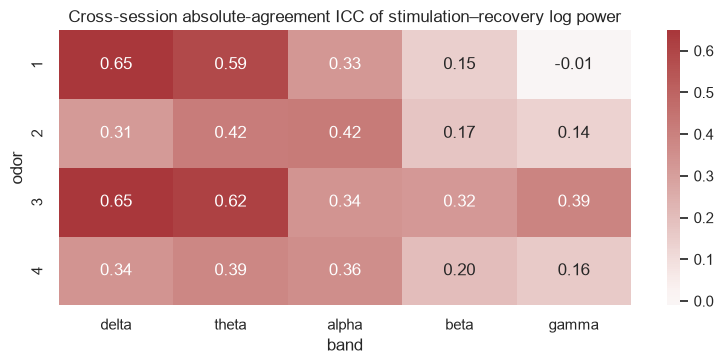

,odor,feature_family,band,n_subjects,n_sessions,icc2_1,ci95_lower,ci95_upper
8,1,relbp,beta,32,3,0.8327,0.3467,0.8982
28,3,relbp,beta,32,3,0.7424,0.5129,0.8370
20,3,logbp,delta,32,3,0.6486,0.3865,0.7891
0,1,logbp,delta,32,3,0.6467,0.2888,0.7917
21,3,logbp,theta,32,3,0.6162,0.4451,0.7179
1,1,logbp,theta,32,3,0.5878,0.3221,0.7503
5,1,relbp,delta,32,3,0.5416,0.2313,0.7569
6,1,relbp,theta,32,3,0.5246,0.3437,0.6858
26,3,relbp,theta,32,3,0.4760,0.2701,0.6493
17,2,relbp,alpha,32,3,0.4524,0.3132,0.6609


In [4]:
icc_heatmap = reliability[reliability.feature_family == "logbp"].pivot(
    index="odor", columns="band", values="icc2_1"
)
icc_heatmap = icc_heatmap.reindex(columns=["delta", "theta", "alpha", "beta", "gamma"])
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(icc_heatmap, annot=True, fmt=".2f", center=0, cmap="vlag", ax=ax)
ax.set_title("Cross-session absolute-agreement ICC of stimulation–recovery log power")
plt.tight_layout()
plt.show()
display(reliability.sort_values("icc2_1", ascending=False).head(15).round(4))


### 4. Leakage-safe prediction baselines

,protocol,model,subset,n_trials,prevalence,log_loss,brier,balanced_accuracy,roc_auc,pr_auc
8,losession,odor_prior,all,2304,0.4332,0.4135,0.1299,0.8247,0.8869,0.8528
6,losession,odor_eeg_stim_logit,all,2304,0.4332,0.6109,0.1895,0.7180,0.7895,0.7420
2,losession,global_prior,all,2304,0.4332,0.6851,0.2460,0.5194,0.5496,0.4560
4,losession,odor_eeg_paired_logit,all,2304,0.4332,0.7039,0.2278,0.6255,0.6864,0.6429
12,losession,odor_riemann_stim_logit,all,2304,0.4332,0.7331,0.2617,0.5363,0.5647,0.4990
0,losession,eeg_stim_logit,all,2304,0.4332,0.7340,0.2607,0.5406,0.5487,0.4721
14,losession,riemann_stim_logit,all,2304,0.4332,0.7351,0.2635,0.5297,0.5556,0.4906
10,losession,odor_riemann_relative_logit,all,2304,0.4332,0.7386,0.2654,0.5186,0.5461,0.4596
24,loso,odor_prior,all,2304,0.4332,0.4411,0.1385,0.8093,0.8142,0.7593
22,loso,odor_eeg_stim_logit,all,2304,0.4332,0.4464,0.1409,0.7840,0.8579,0.8336


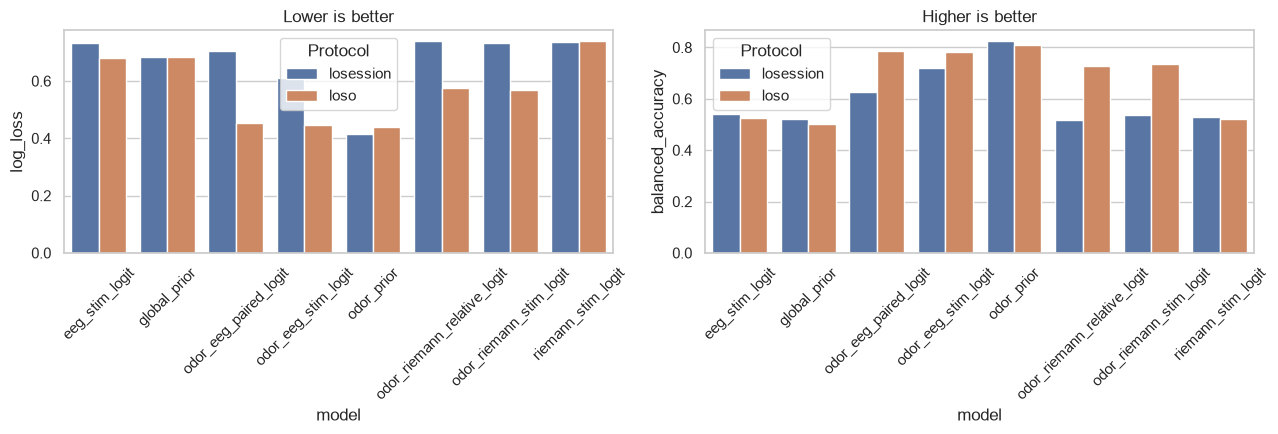

In [5]:
overall = prediction_summary[prediction_summary.subset == "all"].copy()
display(overall.sort_values(["protocol", "log_loss"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=overall, x="model", y="log_loss", hue="protocol", ax=axes[0])
sns.barplot(data=overall, x="model", y="balanced_accuracy", hue="protocol", ax=axes[1])
for ax, title in zip(axes, ["Lower is better", "Higher is better"], strict=True):
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Protocol")
plt.tight_layout()
plt.show()


### 5. Odor-prior disagreement trials

In [6]:
disagreement = prediction_summary[
    prediction_summary.subset == "odor_prior_disagreement"
].copy()
display(disagreement.sort_values(["protocol", "log_loss"]).round(4))
display(incremental_value.sort_values(["protocol", "subset", "mean_log_loss_improvement"], ascending=[True, True, False]).round(4))


,protocol,model,subset,n_trials,prevalence,log_loss,brier,balanced_accuracy,roc_auc,pr_auc
3,losession,global_prior,odor_prior_disagreement,402,0.4502,0.7738,0.2881,0.3704,0.3355,0.3606
15,losession,riemann_stim_logit,odor_prior_disagreement,402,0.4502,0.8038,0.2961,0.4498,0.4468,0.4418
13,losession,odor_riemann_stim_logit,odor_prior_disagreement,402,0.4502,0.8080,0.2983,0.4393,0.4406,0.4436
1,losession,eeg_stim_logit,odor_prior_disagreement,402,0.4502,0.8714,0.3135,0.4568,0.3812,0.3911
11,losession,odor_riemann_relative_logit,odor_prior_disagreement,402,0.4502,0.8802,0.3277,0.3940,0.3568,0.3605
5,losession,odor_eeg_paired_logit,odor_prior_disagreement,402,0.4502,1.2128,0.3872,0.3603,0.2792,0.3364
9,losession,odor_prior,odor_prior_disagreement,402,0.4502,1.4261,0.5349,0.0000,0.0000,0.3123
7,losession,odor_eeg_stim_logit,odor_prior_disagreement,402,0.4502,1.5403,0.4615,0.3256,0.2235,0.3144
17,loso,eeg_stim_logit,odor_prior_disagreement,452,0.3296,0.6520,0.2298,0.5245,0.5642,0.3928
19,loso,global_prior,odor_prior_disagreement,452,0.3296,0.6594,0.2332,0.5000,0.2494,0.2339


,protocol,subset,model,baseline,n_subjects,n_trials,mean_log_loss_improvement,ci95_lower,ci95_upper,subjects_improved_rate
2,losession,all,odor_eeg_stim_logit,odor_prior,32,2304,-0.1974,-0.2551,-0.1451,0.0625
1,losession,all,odor_eeg_paired_logit,odor_prior,32,2304,-0.2905,-0.3604,-0.2257,0.0312
4,losession,all,odor_riemann_stim_logit,odor_prior,32,2304,-0.3196,-0.3830,-0.2569,0.0312
0,losession,all,eeg_stim_logit,odor_prior,32,2304,-0.3205,-0.3706,-0.2683,0.0000
5,losession,all,riemann_stim_logit,odor_prior,32,2304,-0.3217,-0.3828,-0.2613,0.0312
3,losession,all,odor_riemann_relative_logit,odor_prior,32,2304,-0.3252,-0.3864,-0.2686,0.0312
10,losession,odor_prior_disagreement,odor_riemann_stim_logit,odor_prior,31,402,0.8790,0.6594,1.1161,0.9677
11,losession,odor_prior_disagreement,riemann_stim_logit,odor_prior,31,402,0.8732,0.6668,1.1004,0.9677
6,losession,odor_prior_disagreement,eeg_stim_logit,odor_prior,31,402,0.8032,0.5987,1.0166,0.9677
9,losession,odor_prior_disagreement,odor_riemann_relative_logit,odor_prior,31,402,0.7993,0.6108,1.0106,1.0000


## Takeaways

1. The leakage-safe baseline is operational at the participant, session, and trial levels.
2. The paired EEG model did not improve leave-one-subject-out log loss relative to odor identity by **0.014** in this first feature set.
3. Any EEG benefit must remain after participant-level uncertainty analysis and on odor-prior disagreement trials before it is interpreted as personalized response information.
4. Cross-session reliability results should guide feature selection and future repetition counts; low reliability is evidence against using a feature for personalization.
5. The next justified work is an odor-controlled disagreement/residual target plus channel-resolved differential-entropy features. EEGNet and TSception are appropriate compact deep comparisons after that reframing; DSEN remains deferred until authoritative code or a complete specification is available.
